In [1]:
#Common Model Algorithms
from sklearn import svm, tree, linear_model, neighbors, naive_bayes, ensemble, discriminant_analysis, gaussian_process
from xgboost import XGBClassifier

#Common Model Helpers
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn import feature_selection
from sklearn import model_selection
from sklearn import metrics

#Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns
# from pandas.tools.plotting import scatter_matrix


In [2]:


import numpy as np
import tensorflow as tf
import pandas as pd
import random
import keras

import math
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from scipy.stats import chi2_contingency, ttest_ind
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier)
import xgboost as xgb
import pprint
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.tree import DecisionTreeClassifier


In [3]:

#Configure Visualization Defaults
#%matplotlib inline = show plots in Jupyter Notebook browser
%matplotlib inline
mpl.style.use('ggplot')
sns.set_style('white')
pylab.rcParams['figure.figsize'] = 12,8

In [4]:


pd.set_option('max_columns', None)


train_csv = "../input/datawiz-2021-round-2/train.csv"
test_csv = "../input/datawiz-2021-round-2/test.csv"
SS_csv = "../input/datawiz-2021-round-2/sample_submission.csv"

X = pd.read_csv(train_csv)
test_data = pd.read_csv(test_csv)
ss = pd.read_csv(SS_csv)

Categorical_cols = ['Role', 'Invested in Real Estate', 'Extra Hours',
       'Invested in Stock Market', 'Favourite Sport', 'Gender','Languages Known','Average no. of leaves/month','Married(1/0)',
       'Level of Education','ID Proof','Most Productive Hour']

Continious_cols = ['Sport Knowledge (in XP)','Trades Done','Pay','Tax Category', 'Income Category', 'Tax Paid']

Target_col = ['Occupation']

In [5]:

for var in Categorical_cols: 
    
    print(X[var].value_counts())

Full-time    15830
Part-time    15722
Name: Role, dtype: int64
Ocean Side      15364
Country Side    12268
Name: Invested in Real Estate, dtype: int64
Paid      25719
Unpaid     5833
Name: Extra Hours, dtype: int64
Tesla    27919
Jio       3633
Name: Invested in Stock Market, dtype: int64
swimming      4042
polo          3982
None          3953
cricket       3936
soccer        3913
badminton     3913
basketball    3886
Name: Favourite Sport, dtype: int64
male      15788
female    15764
Name: Gender, dtype: int64
1    7928
2    7927
3    7877
4    7820
Name: Languages Known, dtype: int64
1    5355
4    5273
2    5273
5    5235
3    5229
0    5187
Name: Average no. of leaves/month, dtype: int64
 0    18404
 1     9609
-1     3539
Name: Married(1/0), dtype: int64
Graduation     16172
Masters         9310
High School     4777
Name: Level of Education, dtype: int64
Aadhar             20460
Driving License     9116
PAN                 1976
Name: ID Proof, dtype: int64
8     9653
5     4753
1

In [6]:
# view frequency distribution of categorical variables

for var in Categorical_cols: 
    
    print(X[var].value_counts()/np.float(len(X)))

Full-time    0.501711
Part-time    0.498289
Name: Role, dtype: float64
Ocean Side      0.486942
Country Side    0.388818
Name: Invested in Real Estate, dtype: float64
Paid      0.815131
Unpaid    0.184869
Name: Extra Hours, dtype: float64
Tesla    0.884857
Jio      0.115143
Name: Invested in Stock Market, dtype: float64
swimming      0.128106
polo          0.126204
None          0.125285
cricket       0.124746
soccer        0.124017
badminton     0.124017
basketball    0.123162
Name: Favourite Sport, dtype: float64
male      0.50038
female    0.49962
Name: Gender, dtype: float64
1    0.251268
2    0.251236
3    0.249651
4    0.247845
Name: Languages Known, dtype: float64
1    0.169720
4    0.167121
2    0.167121
5    0.165917
3    0.165726
0    0.164395
Name: Average no. of leaves/month, dtype: float64
 0    0.583291
 1    0.304545
-1    0.112164
Name: Married(1/0), dtype: float64
Graduation     0.512551
Masters        0.295068
High School    0.151401
Name: Level of Education, dtype: f

In [7]:
#check if null
print(X.isnull().sum() )
print("\n\n",test_data.isnull().sum())


Role                              0
Invested in Real Estate        3920
Extra Hours                       0
Invested in Stock Market          0
Favourite Sport                3927
Gender                            0
Languages Known                   0
Sport Knowledge (in XP)        4352
Average no. of leaves/month       0
Trades Done                       0
Married(1/0)                      0
Level of Education             1293
Occupation                        0
Pay                            1816
ID Proof                          0
Most Productive Hour              0
Tax Category                      0
Income Category                 923
Employer                       4520
Tax Paid                          0
Id                                0
dtype: int64


 Role                              0
Invested in Real Estate        1732
Extra Hours                       0
Invested in Stock Market          0
Favourite Sport                1669
Gender                            0
Languages Kn

In [8]:
#check null values
print(X[X.columns[X.isnull().any()]].isnull().sum())
print("\nTEST DATA\n",test_data[test_data.columns[test_data.isnull().any()]].isnull().sum())

Invested in Real Estate    3920
Favourite Sport            3927
Sport Knowledge (in XP)    4352
Level of Education         1293
Pay                        1816
Income Category             923
Employer                   4520
dtype: int64

TEST DATA
 Invested in Real Estate    1732
Favourite Sport            1669
Sport Knowledge (in XP)    1882
Level of Education          564
Pay                         802
Income Category             406
Employer                   1939
dtype: int64


In [9]:
#check cardinality

for var in Categorical_cols:
    print(var, ' : ', len(X[var].unique()), ' labels')
    
#cardinality is fine afterall 

Role  :  2  labels
Invested in Real Estate  :  3  labels
Extra Hours  :  2  labels
Invested in Stock Market  :  2  labels
Favourite Sport  :  8  labels
Gender  :  2  labels
Languages Known  :  4  labels
Average no. of leaves/month  :  6  labels
Married(1/0)  :  3  labels
Level of Education  :  4  labels
ID Proof  :  3  labels
Most Productive Hour  :  12  labels


In [10]:

numerical = [var for var in X.columns if X[var].dtype!='O']

print('There are {} numerical variables\n'.format(len(numerical)))

print('The numerical variables are :', numerical)

There are 12 numerical variables

The numerical variables are : ['Languages Known', 'Sport Knowledge (in XP)', 'Average no. of leaves/month', 'Trades Done', 'Married(1/0)', 'Occupation', 'Pay', 'Most Productive Hour', 'Tax Category', 'Income Category', 'Tax Paid', 'Id']


In [11]:
X[numerical].head()


,Languages Known,Sport Knowledge (in XP),Average no. of leaves/month,Trades Done,Married(1/0),Occupation,Pay,Most Productive Hour,Tax Category,Income Category,Tax Paid,Id
0,1,NaN,2,56,0,0,2416.73,8,258,2.0,29597,0
1,3,2.0,0,42,1,4,302.73,8,148,2.0,49218,1
2,3,35.0,4,31,0,8,275.73,8,73,2.0,14764,2
3,4,70.0,1,45,0,7,1779.73,8,89,2.0,46868,3
4,3,25.0,5,31,1,11,274.73,8,195,2.0,21859,4


In [12]:
X

#new feature possibilities :
# 1. 

,Role,Invested in Real Estate,Extra Hours,Invested in Stock Market,Favourite Sport,Gender,Languages Known,Sport Knowledge (in XP),Average no. of leaves/month,Trades Done,Married(1/0),Level of Education,Occupation,Pay,ID Proof,Most Productive Hour,Tax Category,Income Category,Employer,Tax Paid,Id
0,Part-time,NaN,Paid,Tesla,swimming,female,1,NaN,2,56,0,Masters,0,2416.73,Driving License,8,258,2.0,NaN,29597,0
1,Full-time,Ocean Side,Paid,Tesla,cricket,female,3,2.0,0,42,1,Graduation,4,302.73,Driving License,8,148,2.0,Vision-Analytics,49218,1
2,Full-time,Ocean Side,Unpaid,Tesla,soccer,male,3,35.0,4,31,0,Graduation,8,275.73,Driving License,8,73,2.0,Vision-Analytics,14764,2
3,Full-time,Ocean Side,Paid,Tesla,polo,female,4,70.0,1,45,0,NaN,7,1779.73,Driving License,8,89,2.0,Vision-Analytics,46868,3
4,Part-time,Country Side,Paid,Tesla,soccer,male,3,25.0,5,31,1,NaN,11,274.73,Driving License,8,195,2.0,Vision-Analytics,21859,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31547,Full-time,Country Side,Unpaid,Jio,polo,female,1,24.0,4,23,1,Graduation,4,778.73,Aadhar,9,383,2.0,Vision-Analytics,13605,45205
31548,Part-time,Country Side,Paid,Jio,swimming,female,3,98.0,5,49,0,Masters,4,1098.73,Aadhar,9,974,2.0,NaN,22843,45206
31549,Full-time,Country Side,Paid,Jio,badminton,female,2,NaN,5,69,-1,High School,10,NaN,Aadhar,9,453,2.0,Vision-Analytics,36802,45207
31550,Part-time,NaN,Paid,Jio,None,female,1,67.0,5,70,0,Graduation,10,5988.73,Aadhar,9,1124,5.0,Vision-Analytics,15944,45208


In [13]:
X.describe()

,Languages Known,Sport Knowledge (in XP),Average no. of leaves/month,Trades Done,Married(1/0),Occupation,Pay,Most Productive Hour,Tax Category,Income Category,Tax Paid,Id
count,31552.000000,27200.000000,31552.000000,31552.000000,31552.000000,31552.000000,29736.000000,31552.000000,31552.000000,30629.000000,31552.000000,31552.000000
mean,2.494073,49.184081,2.499208,38.949132,0.192381,4.350311,1662.234787,5.526686,255.918294,2.578602,30036.227371,22606.419149
std,1.117242,28.994146,1.704595,10.599705,0.616207,3.072817,3043.201986,3.012496,258.693158,2.453272,11580.364601,13051.028327
min,1.000000,0.000000,0.000000,16.000000,-1.000000,0.000000,0.270000,0.000000,-3.000000,2.000000,10000.000000,0.000000
25%,1.000000,24.000000,1.000000,31.000000,0.000000,2.000000,354.730000,3.000000,100.000000,2.000000,19965.750000,11258.750000
50%,2.000000,49.000000,2.000000,37.000000,0.000000,4.000000,733.730000,6.000000,177.000000,2.000000,30048.000000,22642.500000
75%,3.000000,74.000000,4.000000,46.000000,1.000000,7.000000,1709.980000,8.000000,317.000000,2.000000,40025.000000,33901.250000
max,4.000000,99.000000,5.000000,93.000000,1.000000,11.000000,102400.730000,11.000000,4915.000000,277.000000,49999.000000,45209.000000


In [14]:
 X[X["Sport Knowledge (in XP)"] > 60]

,Role,Invested in Real Estate,Extra Hours,Invested in Stock Market,Favourite Sport,Gender,Languages Known,Sport Knowledge (in XP),Average no. of leaves/month,Trades Done,Married(1/0),Level of Education,Occupation,Pay,ID Proof,Most Productive Hour,Tax Category,Income Category,Employer,Tax Paid,Id
3,Full-time,Ocean Side,Paid,Tesla,polo,female,4,70.0,1,45,0,NaN,7,1779.73,Driving License,8,89,2.0,Vision-Analytics,46868,3
5,Part-time,Ocean Side,Paid,Tesla,None,female,1,82.0,3,40,-1,Masters,8,275.73,Driving License,8,377,2.0,NaN,23961,7
6,Part-time,NaN,Paid,Tesla,None,male,1,63.0,5,56,0,High School,10,394.73,Driving License,8,47,2.0,Vision-Analytics,20364,8
8,Full-time,Ocean Side,Paid,Tesla,basketball,male,2,96.0,0,39,-1,Graduation,3,543.73,Driving License,8,219,NaN,Vision-Analytics,26185,10
11,Full-time,NaN,Paid,Tesla,soccer,male,1,61.0,5,43,1,NaN,3,286.73,Driving License,8,95,2.0,Vision-Analytics,22664,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31545,Full-time,Country Side,Unpaid,Jio,None,male,1,90.0,0,21,1,Masters,5,386.73,Aadhar,9,263,2.0,Vision-Analytics,12598,45203
31546,Part-time,Country Side,Paid,Jio,soccer,female,1,66.0,1,71,0,Graduation,10,3123.73,Aadhar,9,297,10.0,Vision-Analytics,34942,45204
31548,Part-time,Country Side,Paid,Jio,swimming,female,3,98.0,5,49,0,Masters,4,1098.73,Aadhar,9,974,2.0,NaN,22843,45206
31550,Part-time,NaN,Paid,Jio,None,female,1,67.0,5,70,0,Graduation,10,5988.73,Aadhar,9,1124,5.0,Vision-Analytics,15944,45208


In [15]:
X['Income Category'].value_counts()

2.0      25035
3.0       1871
4.0       1429
5.0        775
6.0        509
7.0        319
8.0        180
9.0        141
10.0        78
11.0        59
12.0        45
13.0        39
14.0        30
15.0        23
17.0        14
16.0        12
19.0         8
18.0         8
21.0         8
25.0         7
26.0         5
24.0         4
22.0         3
27.0         3
31.0         3
29.0         3
20.0         3
39.0         2
32.0         2
28.0         2
40.0         2
60.0         1
23.0         1
42.0         1
34.0         1
43.0         1
277.0        1
30.0         1
Name: Income Category, dtype: int64

In [16]:
X['Sport Knowledge (in XP)'].median()

49.0

In [17]:
def remove_nan_outliers(X):
    X.dropna(subset=['Income Category', 'Pay'], how='all', inplace=True)
    X.dropna(subset=['Sport Knowledge (in XP)', 'Favourite Sport'], how='all', inplace=True)
#     X.dropna(subset=['Employer', 'Level of Education'], how='all', inplace=True)
    
    return X

def remove_nans(X):
    #fill with most freq labels
    
    X.loc[X['Favourite Sport'].isnull() & X['Sport Knowledge (in XP)'].isnull(),'Sport Knowledge (in XP)'] = 0
    X['Favourite Sport'].fillna('swimming', inplace=True) 
    X['Sport Knowledge (in XP)'].fillna(X['Sport Knowledge (in XP)'].median(), inplace=True)

    X.loc[X['Income Category'].isnull() & X['Employer'].isnull(),'Pay'] = 0
    X['Pay'].fillna(X['Pay'].mean(), inplace=True)

    X['Invested in Real Estate'].fillna('Ocean Side', inplace=True)

    X['Level of Education'].fillna('Graduation', inplace=True)

    X['Income Category'].fillna(2.0, inplace=True)
    
#     X["plays"] = 1
#     X.loc[X["Favourite Sport"] == 'None' & X['Sport Knowledge (in XP)']>60, 'plays'] = 0
    X["Married(1/0)"][X["Married(1/0)"] == -1] = 1
    
    X['Employer'].fillna('None', inplace=True) 
    
    X["Tax Category"][X["Tax Category"] <100] = 10001
    X["Tax Category"][X["Tax Category"] <200] = 10002
    X["Tax Category"][X["Tax Category"] <300] = 10003
    X["Tax Category"][X["Tax Category"] <500] = 10004
    X["Tax Category"][X["Tax Category"] <900] = 10005
    X["Tax Category"][X["Tax Category"] <5000] = 10006
    X["Tax Category"] -= 10000
    
#     X["Income Category"][X["Income Category"] <4] = 102
#     X["Income Category"][X["Income Category"] <70] = 101
#     X["Income Category"] -= 100
#     X = X[X['Income Category'] <3] 
#     del X['Tax Category']
    del X['Income Category']
    del X['Employer'] #only has one category in test and train
    del X['Id']       #useless
    
    return X

X = remove_nan_outliers(X)
X = remove_nans(X)
test_data = remove_nans(test_data)


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:32: SettingWithCopyWarning: 
A value is trying to b

In [18]:
X

,Role,Invested in Real Estate,Extra Hours,Invested in Stock Market,Favourite Sport,Gender,Languages Known,Sport Knowledge (in XP),Average no. of leaves/month,Trades Done,Married(1/0),Level of Education,Occupation,Pay,ID Proof,Most Productive Hour,Tax Category,Tax Paid
0,Part-time,Ocean Side,Paid,Tesla,swimming,female,1,49.0,2,56,0,Masters,0,2416.730000,Driving License,8,3,29597
1,Full-time,Ocean Side,Paid,Tesla,cricket,female,3,2.0,0,42,1,Graduation,4,302.730000,Driving License,8,2,49218
2,Full-time,Ocean Side,Unpaid,Tesla,soccer,male,3,35.0,4,31,0,Graduation,8,275.730000,Driving License,8,1,14764
3,Full-time,Ocean Side,Paid,Tesla,polo,female,4,70.0,1,45,0,Graduation,7,1779.730000,Driving License,8,1,46868
4,Part-time,Country Side,Paid,Tesla,soccer,male,3,25.0,5,31,1,Graduation,11,274.730000,Driving License,8,2,21859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31547,Full-time,Country Side,Unpaid,Jio,polo,female,1,24.0,4,23,1,Graduation,4,778.730000,Aadhar,9,4,13605
31548,Part-time,Country Side,Paid,Jio,swimming,female,3,98.0,5,49,0,Masters,4,1098.730000,Aadhar,9,6,22843
31549,Full-time,Country Side,Paid,Jio,badminton,female,2,49.0,5,69,1,High School,10,1656.194269,Aadhar,9,4,36802
31550,Part-time,Ocean Side,Paid,Jio,None,female,1,67.0,5,70,0,Graduation,10,5988.730000,Aadhar,9,6,15944


/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


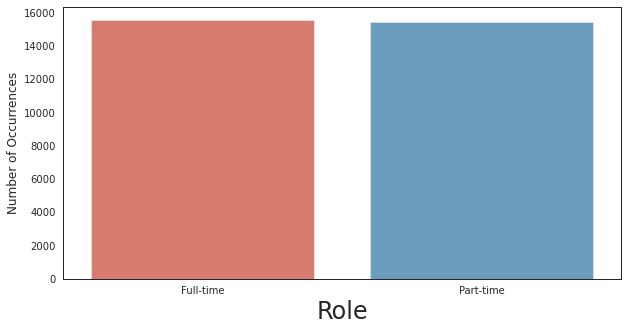

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


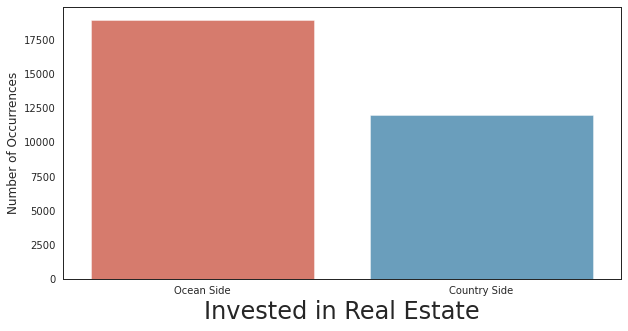

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


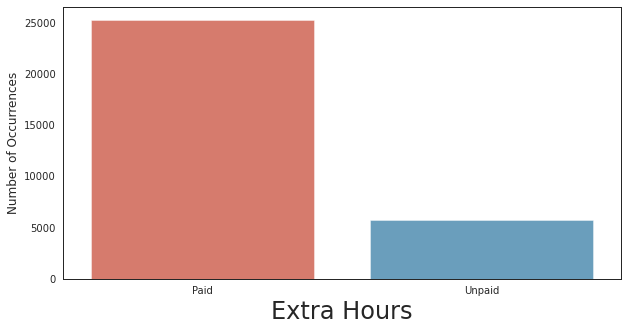

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


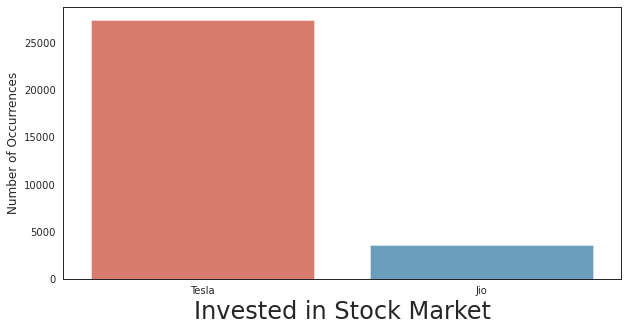

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


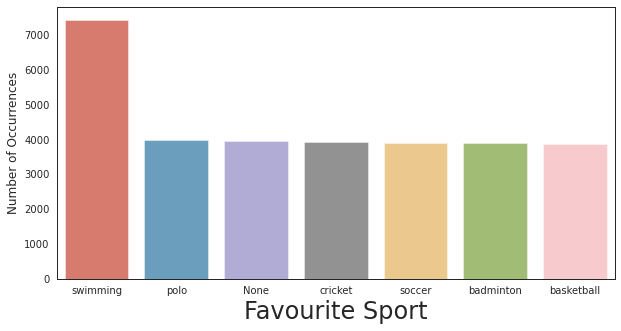

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


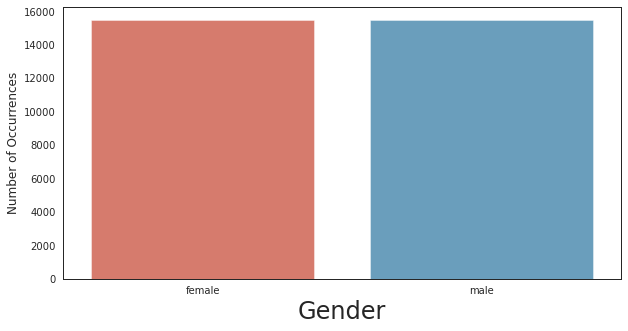

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


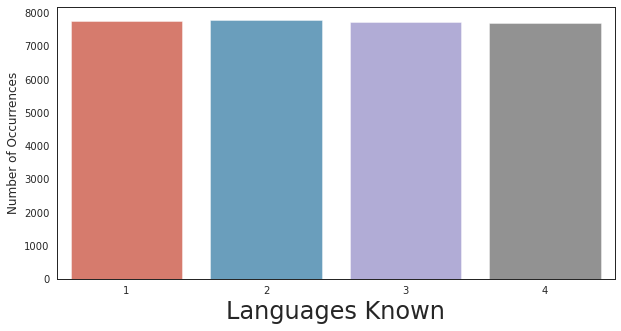

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


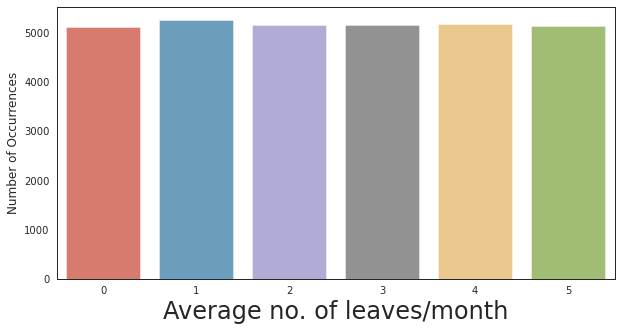

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


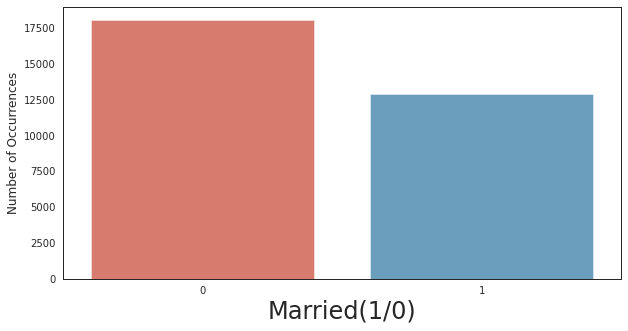

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


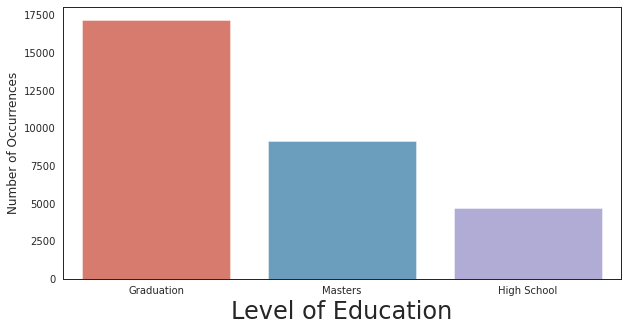

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


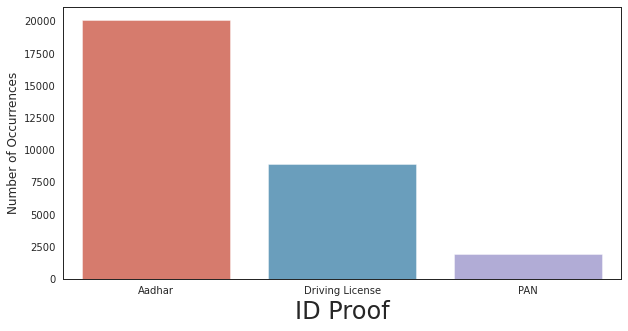

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


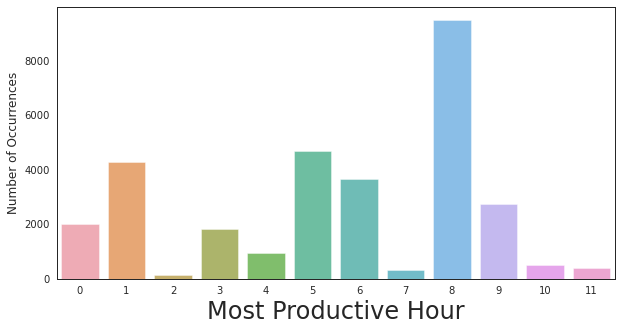

In [19]:
def plot_f(col):
    city_count  = X[col].value_counts()
#     city_count = city_count[:10,]
    plt.figure(figsize=(10,5))
    sns.barplot(city_count.index, city_count.values, alpha=0.8)
    plt.ylabel('Number of Occurrences', fontsize=12)
    plt.xlabel(col, fontsize=24)
    plt.show()
    
def plot_cont(col):
    plt.figure(figsize=(10,5))
    plt.xlabel(col, fontsize=24)
    plt.ylabel('Number of Occurrences', fontsize=12)
    sns.distplot(X[col],bins=100,kde=False)
    plt.show()
    
for i in range(len(Categorical_cols)):
    plot_f(Categorical_cols[i])
    
# for i in range(len(Continious_cols)):
#     plot_f(Continious_cols[i])

# extra hours, invested in stk market, 
# level of edu, id proof, most prod hour, 
# sport in XP, Trades done, tax category, income category,
# marital status handle -1s in test and train


Chi Square test b/w Role and Answer is:  0.685650598588837


<Figure size 360x720 with 0 Axes>

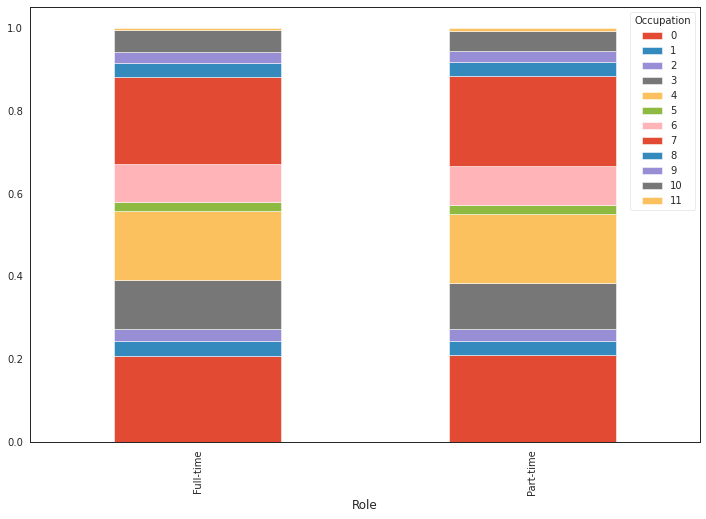

Chi Square test b/w Invested in Real Estate and Answer is:  0.0


<Figure size 360x720 with 0 Axes>

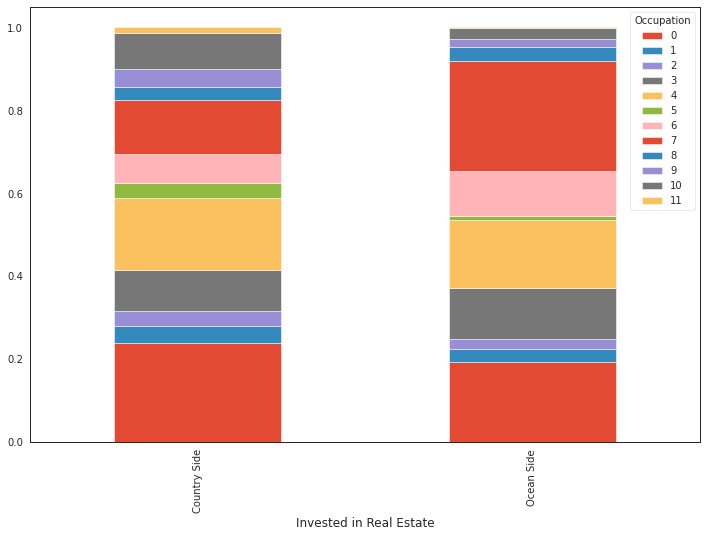

Chi Square test b/w Extra Hours and Answer is:  8.08018413034336e-59


<Figure size 360x720 with 0 Axes>

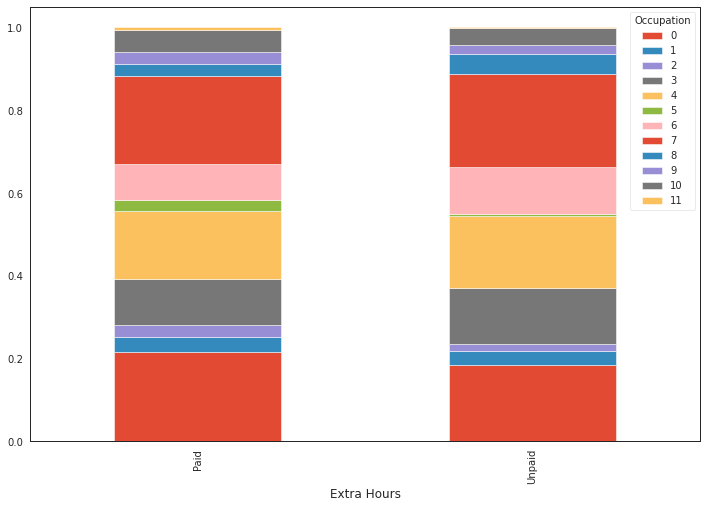

Chi Square test b/w Invested in Stock Market and Answer is:  1.2717882325348225e-119


<Figure size 360x720 with 0 Axes>

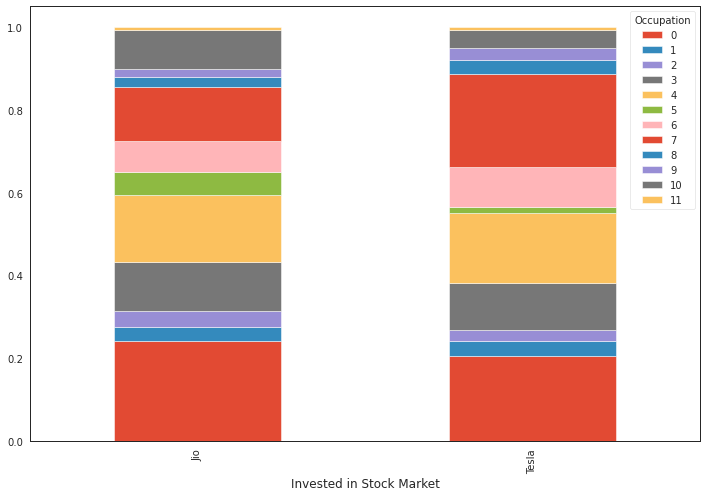

Chi Square test b/w Favourite Sport and Answer is:  0.2826358283574725


<Figure size 360x720 with 0 Axes>

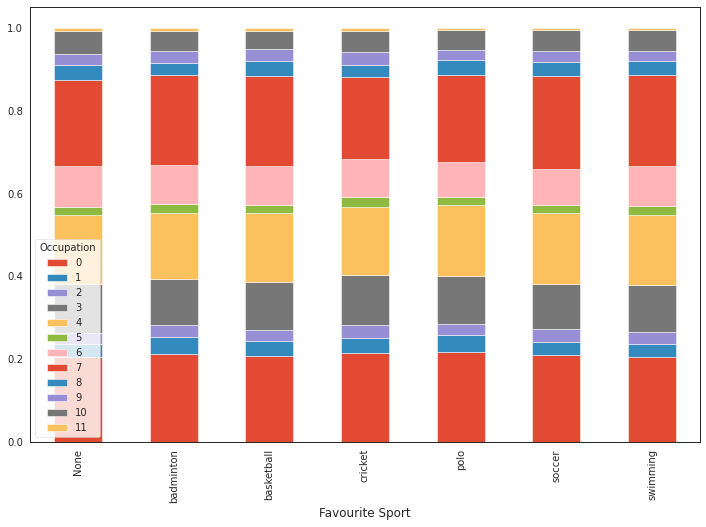

Chi Square test b/w Gender and Answer is:  0.6652134463503443


<Figure size 360x720 with 0 Axes>

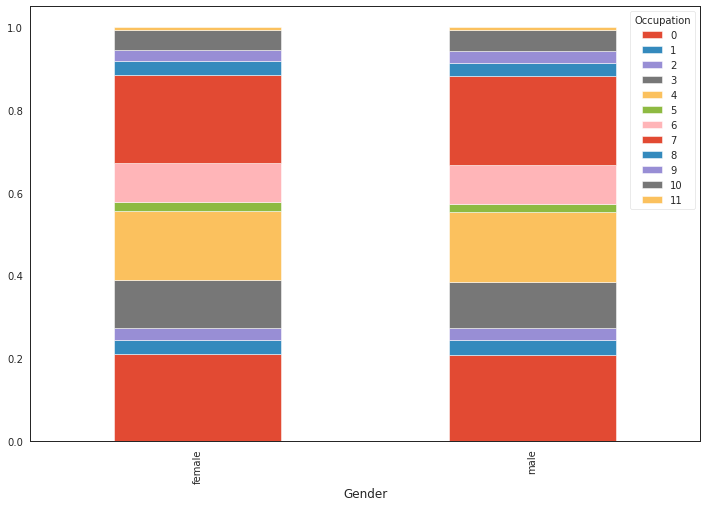

Chi Square test b/w Languages Known and Answer is:  0.24382976291413816


<Figure size 360x720 with 0 Axes>

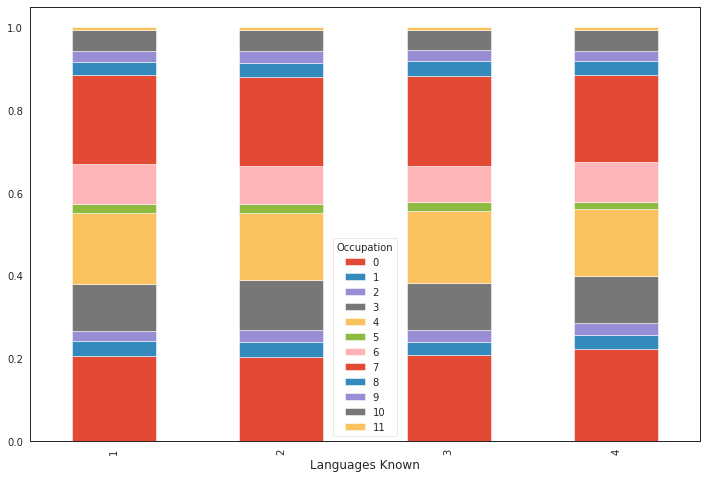

Chi Square test b/w Average no. of leaves/month and Answer is:  0.7447767007002297


<Figure size 360x720 with 0 Axes>

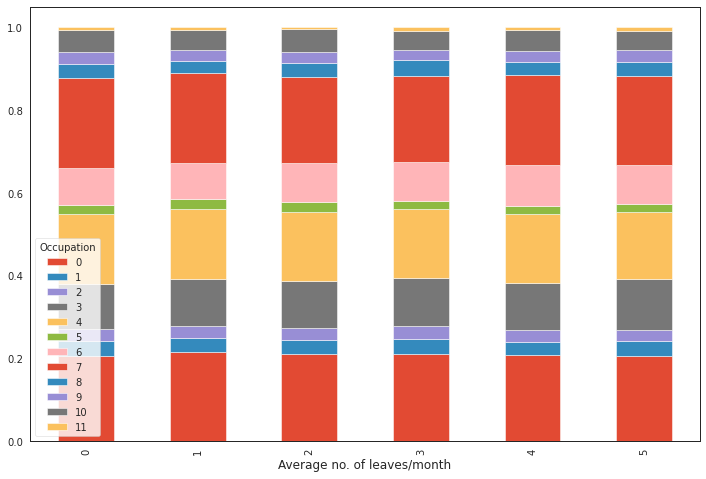

Chi Square test b/w Married(1/0) and Answer is:  0.0


<Figure size 360x720 with 0 Axes>

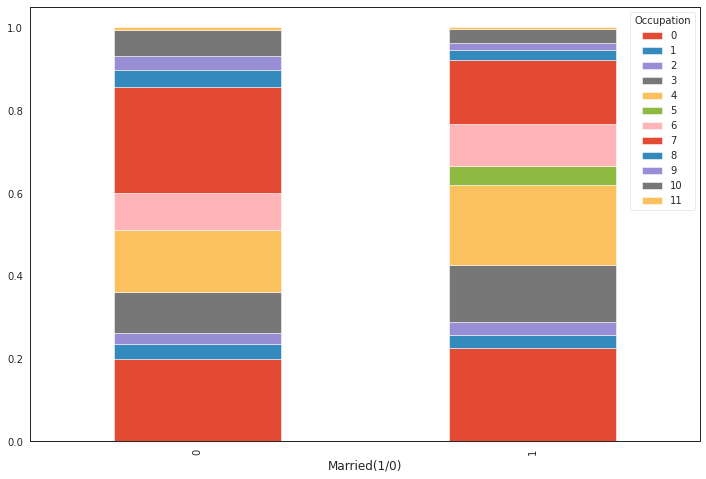

Chi Square test b/w Level of Education and Answer is:  0.0


<Figure size 360x720 with 0 Axes>

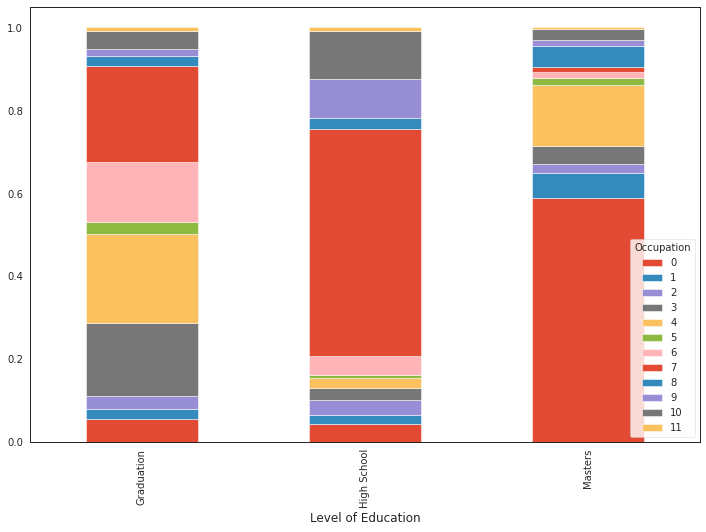

Chi Square test b/w ID Proof and Answer is:  1.4682795216972393e-291


<Figure size 360x720 with 0 Axes>

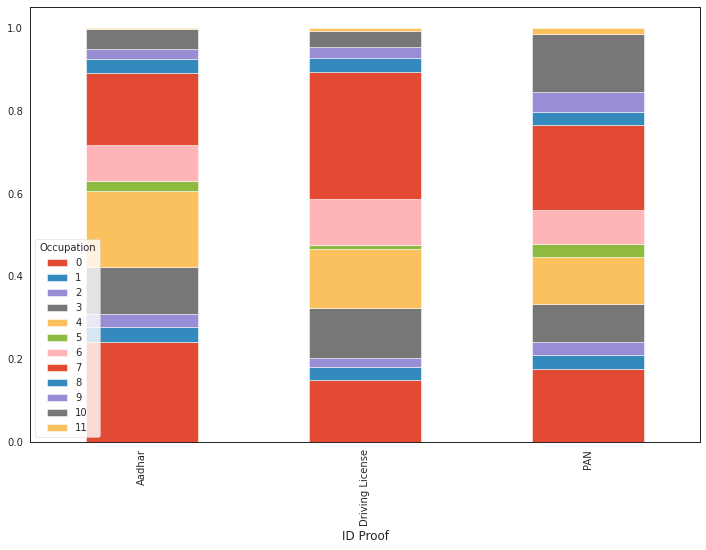

Chi Square test b/w Most Productive Hour and Answer is:  0.0


<Figure size 360x720 with 0 Axes>

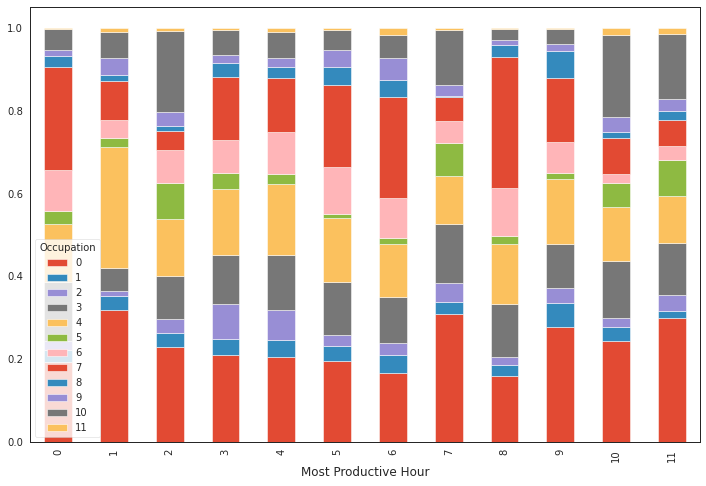

In [20]:
func1 = lambda r: r/r.sum()

for i in Categorical_cols:
    plt.figure(figsize=(5, 10))
    stackCol = pd.crosstab(X[i], X["Occupation"])
    print(f"Chi Square test b/w {i} and Answer is: ", stats.chi2_contingency(np.array(stackCol))[1])
    stackCol = stackCol.apply(func1, axis=1)
    stackCol.plot(kind='bar', stacked=True)
    plt.show()

In [21]:
LE = LabelEncoder()

def string_to_num(col, X):
    X[col] = LE.fit_transform(X[col])
    return X

X = string_to_num("Role", X)
X = string_to_num("Invested in Real Estate", X)
X = string_to_num("Extra Hours", X)
X = string_to_num("Invested in Stock Market", X)
X = string_to_num("Favourite Sport", X)
X = string_to_num("Gender", X)
X = string_to_num("Level of Education", X)
X = string_to_num("ID Proof", X)
X = string_to_num("Most Productive Hour", X)
# X = string_to_num("Employer", X)

test_data = string_to_num("Most Productive Hour", test_data)
test_data = string_to_num("Role", test_data)
test_data = string_to_num("Invested in Real Estate", test_data)
test_data = string_to_num("Extra Hours", test_data)
test_data = string_to_num("Invested in Stock Market", test_data)
test_data = string_to_num("Favourite Sport", test_data)
test_data = string_to_num("Gender", test_data)
test_data = string_to_num("Level of Education", test_data)
test_data = string_to_num("ID Proof", test_data)
# test_data = string_to_num("Employer", test_data)


In [22]:
X

,Role,Invested in Real Estate,Extra Hours,Invested in Stock Market,Favourite Sport,Gender,Languages Known,Sport Knowledge (in XP),Average no. of leaves/month,Trades Done,Married(1/0),Level of Education,Occupation,Pay,ID Proof,Most Productive Hour,Tax Category,Tax Paid
0,1,1,0,1,6,0,1,49.0,2,56,0,2,0,2416.730000,1,8,3,29597
1,0,1,0,1,3,0,3,2.0,0,42,1,0,4,302.730000,1,8,2,49218
2,0,1,1,1,5,1,3,35.0,4,31,0,0,8,275.730000,1,8,1,14764
3,0,1,0,1,4,0,4,70.0,1,45,0,0,7,1779.730000,1,8,1,46868
4,1,0,0,1,5,1,3,25.0,5,31,1,0,11,274.730000,1,8,2,21859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31547,0,0,1,0,4,0,1,24.0,4,23,1,0,4,778.730000,0,9,4,13605
31548,1,0,0,0,6,0,3,98.0,5,49,0,2,4,1098.730000,0,9,6,22843
31549,0,0,0,0,1,0,2,49.0,5,69,1,1,10,1656.194269,0,9,4,36802
31550,1,1,0,0,0,0,1,67.0,5,70,0,0,10,5988.730000,0,9,6,15944


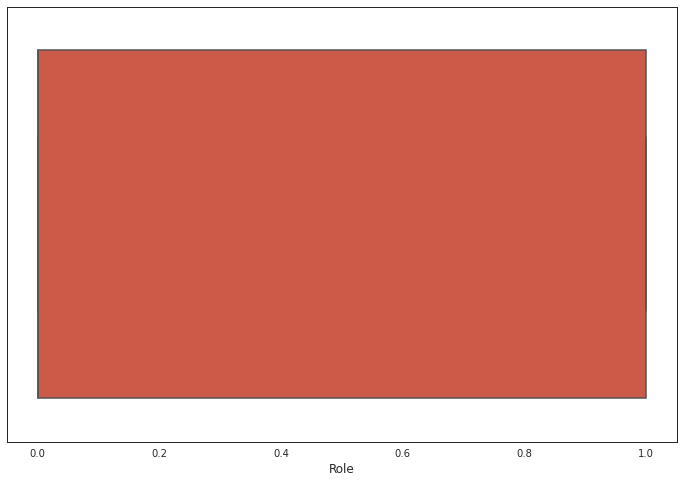

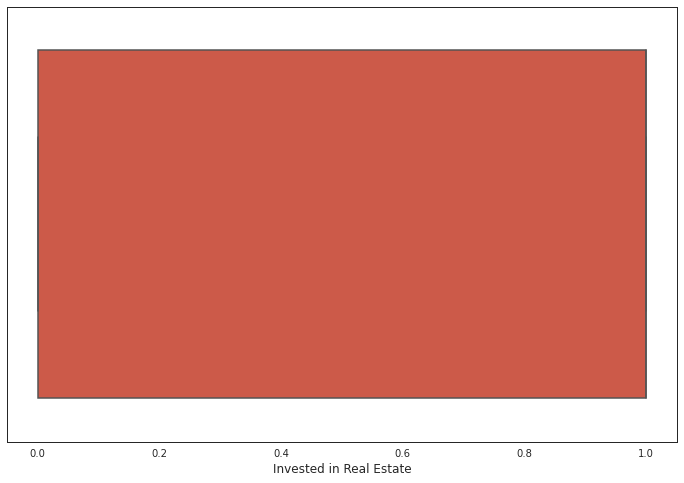

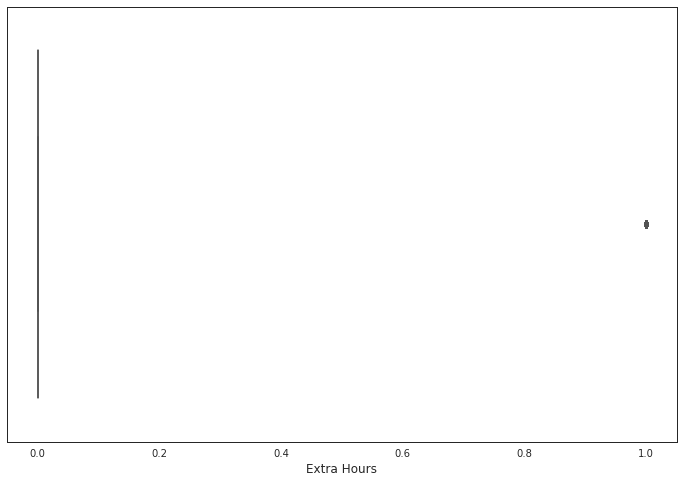

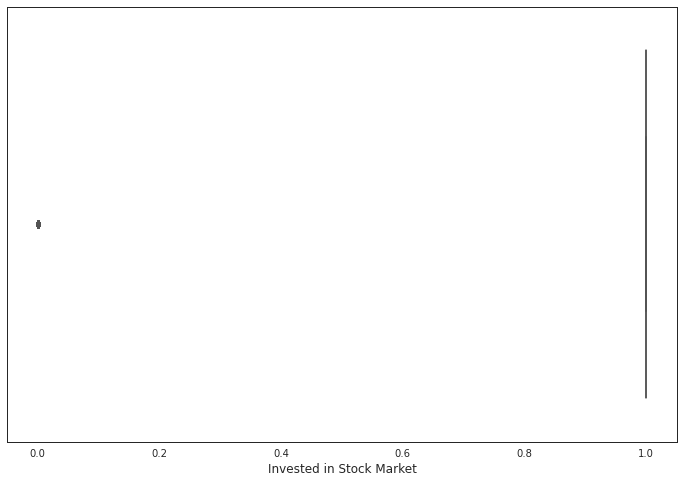

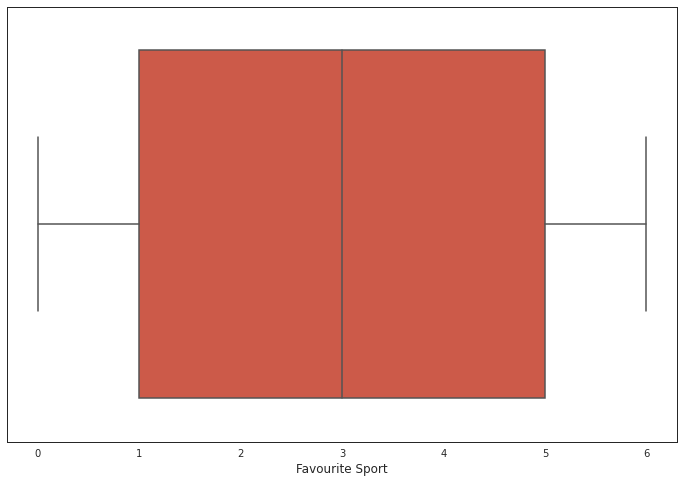

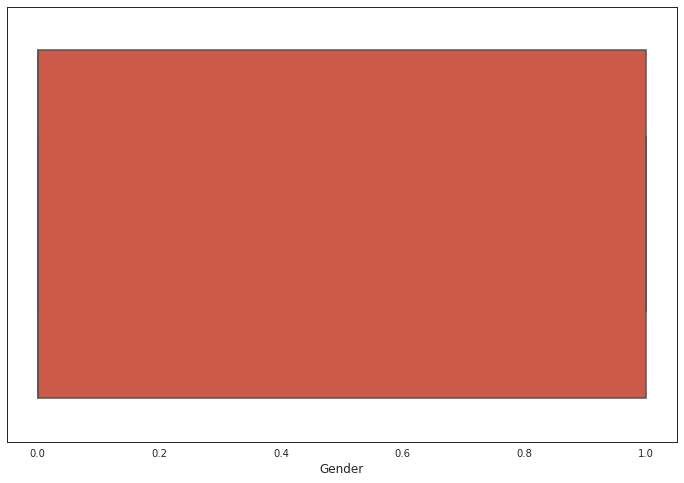

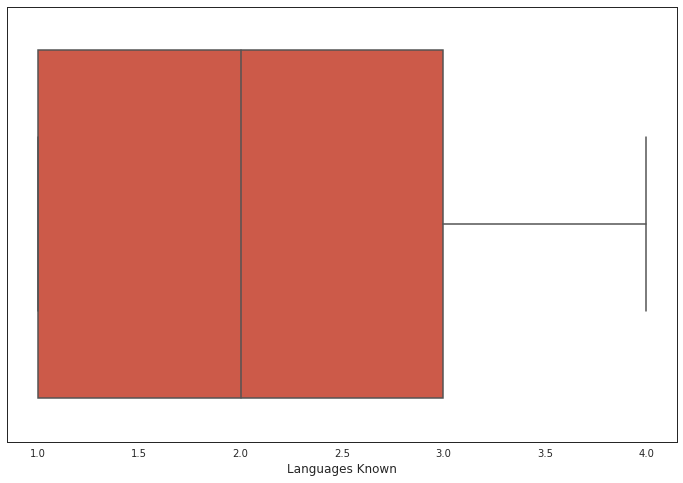

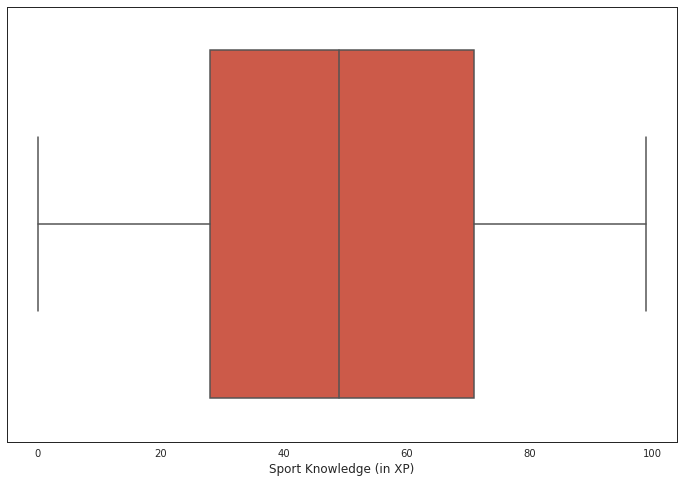

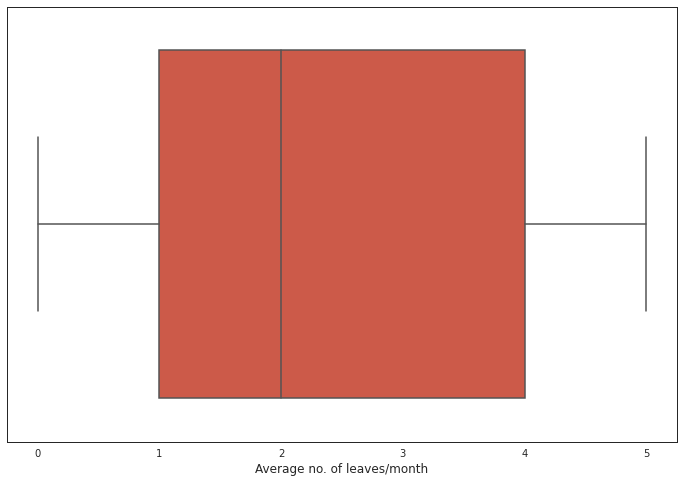

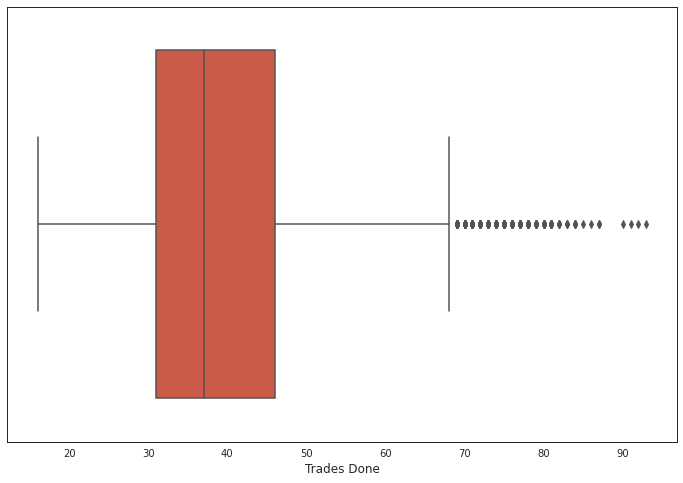

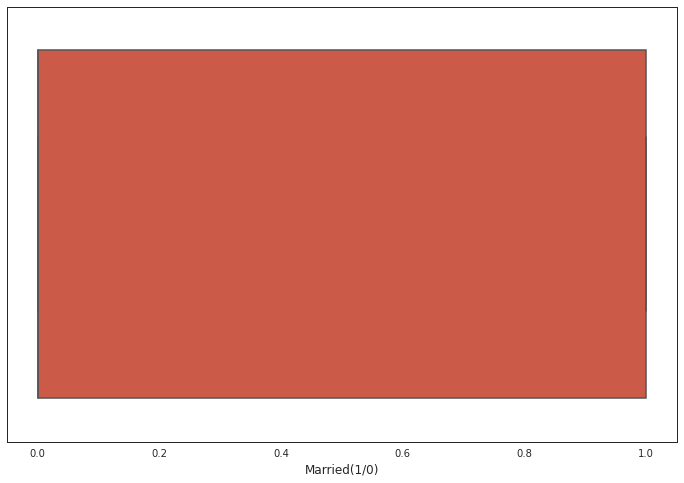

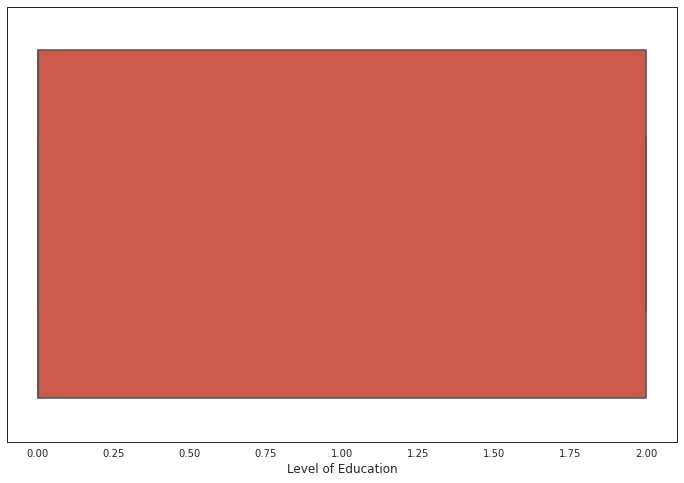

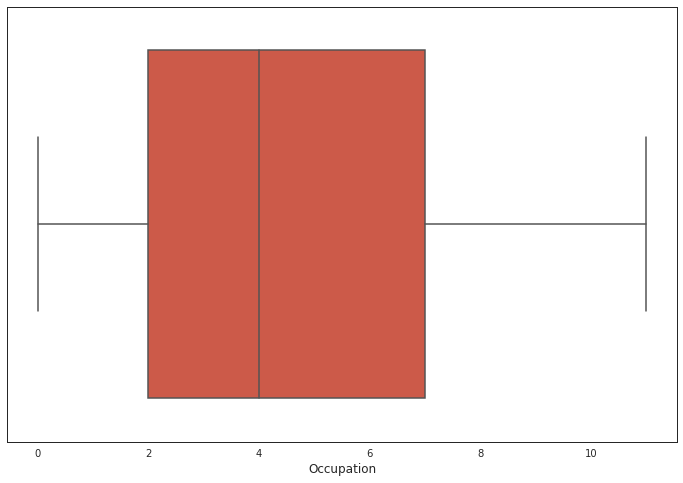

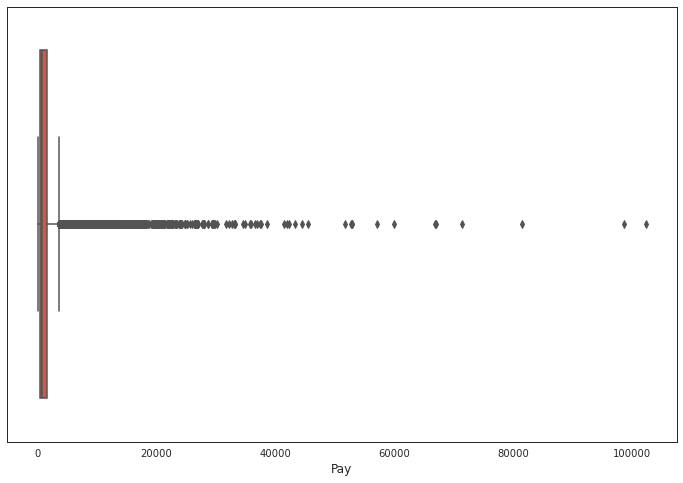

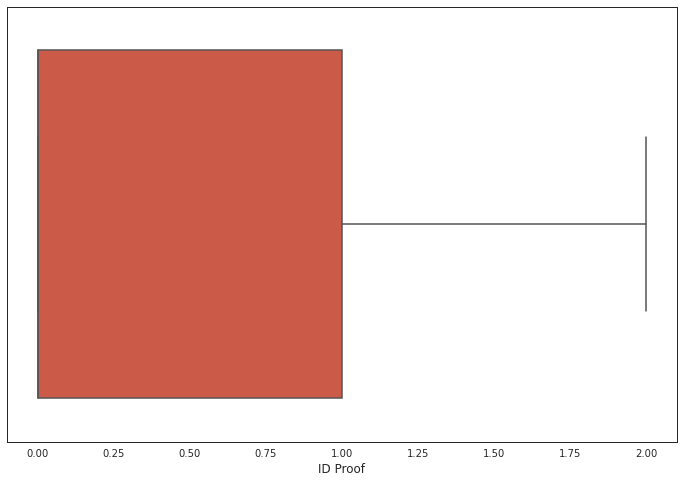

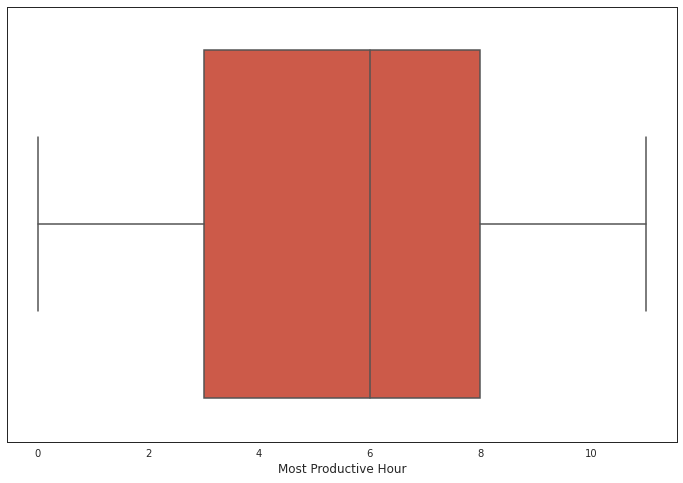

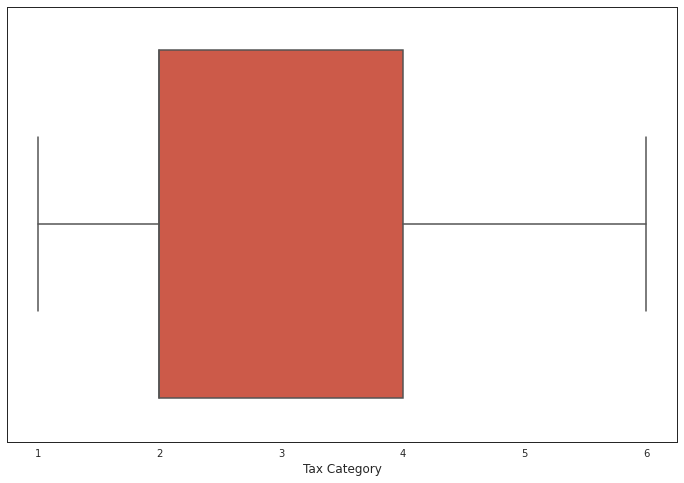

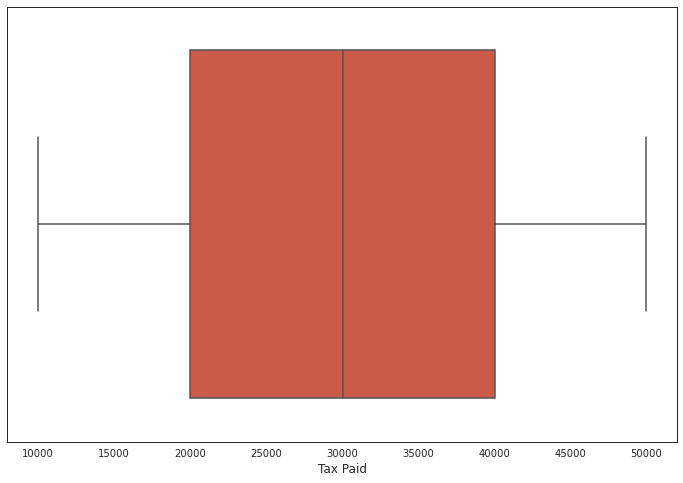

In [23]:
for i in X.columns:
    sns.boxplot(x=i, hue="Occupation", data=X)
    plt.show()

In [24]:
# remove outliers


range_lst = []
out_list = ['Trades Done','Pay']

for i in out_list:
    q25, q75 = X[i].quantile(0.25), X[i].quantile(0.75)
    iqr = q75-q25
    cut_off = iqr*1.5
    lower, upper = q25-cut_off, q75+cut_off
    range_lst.append((lower, upper))
print(range_lst)

print(X.shape)
X = X[(X["Trades Done"]>range_lst[0][0]) & (X["Trades Done"]<range_lst[0][1])]
# X = X[(X["Pay"]>range_lst[1][0]) & (X["Pay"]<range_lst[1][1])]
print(X.shape)

[(8.5, 68.5), (-1564.966403063756, 3588.890671772927)]
(30974, 18)
(30645, 18)


In [25]:
print(print(X["Occupation"].value_counts()))
print(X.shape)

factor = max(X.Occupation.value_counts())
for a in [0,1,2,3,4,5,6,8,9,10,11]:
    df_majority = X[X.Occupation!=a]
    df_minority = X[X.Occupation==a]
#     Upsample minority class
    df_minority_upsampled = resample(df_minority, 
                                     replace = True,     # sample with replacement
                                     n_samples = factor,    # to match majority class
                                     random_state = 123) # reproducible results
    X =  pd.concat([df_majority, df_minority_upsampled])
    
print(X.shape)

y = X["Occupation"]

X.drop(['Occupation'],axis=1, inplace=True)
X

7     6633
0     6487
4     5170
3     3548
6     2873
10    1258
1     1082
8     1029
2      881
9      833
5      653
11     198
Name: Occupation, dtype: int64
None
(30645, 18)
(79596, 18)


,Role,Invested in Real Estate,Extra Hours,Invested in Stock Market,Favourite Sport,Gender,Languages Known,Sport Knowledge (in XP),Average no. of leaves/month,Trades Done,Married(1/0),Level of Education,Pay,ID Proof,Most Productive Hour,Tax Category,Tax Paid
3,0,1,0,1,4,0,4,70.0,1,45,0,0,1779.73,1,8,1,46868
14,1,1,1,1,6,0,2,84.0,0,26,0,0,996.73,1,8,3,16686
16,1,1,1,1,0,0,1,60.0,0,30,1,1,296.73,1,8,2,11107
27,1,1,0,1,6,0,3,49.0,5,23,0,0,266.73,1,8,4,15795
31,0,1,0,1,0,0,4,50.0,2,58,0,0,377.73,1,8,1,19650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6344,0,0,0,1,2,1,4,25.0,0,49,1,0,273.73,1,6,4,26971
23724,1,0,0,1,4,1,4,7.0,0,53,0,2,3840.73,0,0,1,24290
8412,0,0,0,1,4,1,1,52.0,4,55,1,0,589.73,1,6,1,12240
11742,0,0,0,1,0,0,4,68.0,3,57,0,0,675.73,2,5,1,28184


In [26]:
# del X['Extra Hours']
# del X['Invested in Stock Market']

# del test_data['Extra Hours']
# del test_data['Invested in Stock Market']

<AxesSubplot:title={'center':'Pearson Correlation of Features'}>

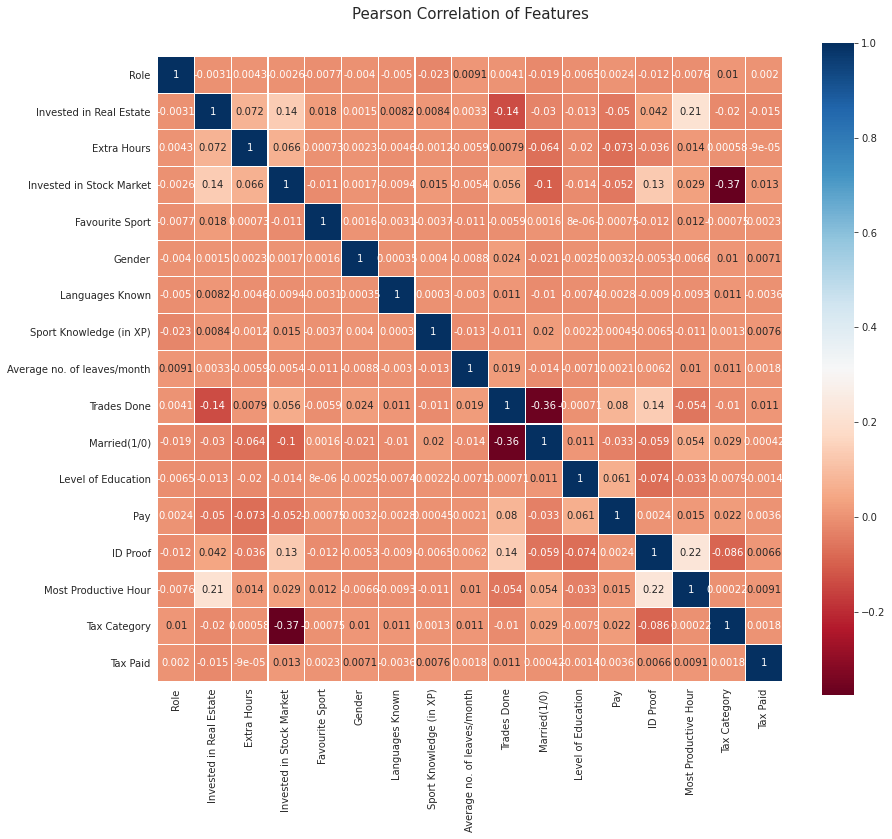

In [27]:
colormap = plt.cm.RdBu
plt.figure(figsize=(14,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.heatmap(X.astype(float).corr(),linewidths=0.1,vmax=1.0, 
            square=True, cmap=colormap, linecolor='white', annot=True)

In [28]:
ss_lst = ['Sport Knowledge (in XP)','Trades Done','Pay', 'Tax Paid']

std_sc = StandardScaler()
std_sc.fit(X[ss_lst])

X_temp = X.copy()
test_data_temp = test_data.copy()

X_temp[ss_lst] = std_sc.transform(X[ss_lst])
test_data_temp[ss_lst] = std_sc.transform(test_data[ss_lst])

X = X_temp
test_data = test_data_temp

In [29]:
#Extra Hours & Invested in Stock Market are binary categories so ignore
Categorical_cols = ['Role', 'Invested in Real Estate','Favourite Sport', 'Gender','Languages Known','Average no. of leaves/month','Married(1/0)',
       'Level of Education','ID Proof','Most Productive Hour', 'Tax Category']

def one_hot_enc(X):
#     X = pd.concat([X,pd.get_dummies(X["Gender"],prefix='Gender')],axis=1)
    for a in Categorical_cols:
        X = pd.concat([X,pd.get_dummies(X[a],prefix=a)],axis=1)
    
    X.drop(Categorical_cols,axis=1, inplace=True)
    return X

X_OHE = one_hot_enc(X)
test_data_OHE = one_hot_enc(test_data)
y_OHE = pd.get_dummies(y)

X_OHE

,Extra Hours,Invested in Stock Market,Sport Knowledge (in XP),Trades Done,Pay,Tax Paid,Role_0,Role_1,Invested in Real Estate_0,Invested in Real Estate_1,Favourite Sport_0,Favourite Sport_1,Favourite Sport_2,Favourite Sport_3,Favourite Sport_4,Favourite Sport_5,Favourite Sport_6,Gender_0,Gender_1,Languages Known_1,Languages Known_2,Languages Known_3,Languages Known_4,Average no. of leaves/month_0,Average no. of leaves/month_1,Average no. of leaves/month_2,Average no. of leaves/month_3,Average no. of leaves/month_4,Average no. of leaves/month_5,Married(1/0)_0,Married(1/0)_1,Level of Education_0,Level of Education_1,Level of Education_2,ID Proof_0,ID Proof_1,ID Proof_2,Most Productive Hour_0,Most Productive Hour_1,Most Productive Hour_2,Most Productive Hour_3,Most Productive Hour_4,Most Productive Hour_5,Most Productive Hour_6,Most Productive Hour_7,Most Productive Hour_8,Most Productive Hour_9,Most Productive Hour_10,Most Productive Hour_11,Tax Category_1,Tax Category_2,Tax Category_3,Tax Category_4,Tax Category_5,Tax Category_6
3,0,1,0.754548,0.485413,0.030766,1.451528,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0
14,1,1,1.266835,-1.210250,-0.245522,-1.148183,0,1,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0
16,1,1,0.388630,-0.853268,-0.492524,-1.628727,0,1,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
27,0,1,-0.013881,-1.477986,-0.503110,-1.224929,0,1,0,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,1,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
31,0,1,0.022711,1.645603,-0.463942,-0.892881,1,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6344,0,1,-0.892086,0.842395,-0.500640,-0.262290,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
23724,0,1,-1.550739,1.199376,0.758009,-0.493217,0,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
8412,0,1,0.095895,1.377867,-0.389136,-1.531137,1,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
11742,0,1,0.681365,1.556358,-0.358790,-0.157809,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0


In [30]:
# from sklearn.preprocessing import RobustScaler
# cols = X_OHE.columns

# scaler = RobustScaler()

# X_OHE = scaler.fit_transform(X_OHE)
# test_data_OHE = scaler.transform(test_data_OHE)

# X_OHE = pd.DataFrame(X_OHE, columns=[cols])
# test_data_OHE = pd.DataFrame(test_data_OHE, columns=[cols])
# X_OHE

In [31]:
X_OHE = X_OHE.values
y_OHE = y_OHE.values
test_data_OHE = test_data_OHE.values
y=y.values

In [32]:
X_train_OHE, X_test_OHE, y_train, y_test = train_test_split(X_OHE, y, test_size=0.3, random_state=42, shuffle=True, stratify=y)


In [33]:
from sklearn.metrics import roc_auc_score

def get_accuracy(y_pred, y):
    return accuracy_score(y_pred, y)

# Random_Forest_CLassifier

In [34]:
from sklearn.metrics import accuracy_score
RFC = RandomForestClassifier()
RFC.fit(X_train_OHE, y_train)

pred_train = RFC.predict(X_train_OHE)
print( "Train acc = ",get_accuracy(y_train, pred_train) )

pred_val = RFC.predict(X_test_OHE)
print( "Validation acc = ",get_accuracy(y_test, pred_val) )

pred_test = RFC.predict(test_data_OHE)
ss["Occupation"] = pred_test
print(ss["Occupation"].value_counts())
print(ss.head())
ss.to_csv('RFC_Submission.csv', index=False)  

#0.91666 - VA test size = 12, any scaling

Train acc =  1.0
Validation acc =  0.8927090749193852
0     3643
7     3500
3     1664
4     1473
6     1299
10    1065
5      361
9      267
1      127
2      125
8       98
11      37
Name: Occupation, dtype: int64
   Id  Occupation
0   5           8
1   6           0
2  11           4
3  12           7
4  13          10


In [35]:
grid_n_estimator = [50, 100, 300, 400, 500, 700, 800]
grid_max_depth = [None]
grid_criterion = ['entropy']
grid_seed = [0]

param=[{
#RandomForestClassifier - http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier
'n_estimators': grid_n_estimator, #default=10
'criterion': grid_criterion, #default=”gini”
'max_depth': grid_max_depth, #default=None
'oob_score': [True], #default=False -- 12/31/17 set to reduce runtime -- The best parameter for RandomForestClassifier is {'criterion': 'entropy', 'max_depth': 6, 'n_estimators': 100, 'oob_score': True, 'random_state': 0} with a runtime of 146.35 seconds.
'random_state': grid_seed
}]

In [36]:
import time
start = time.perf_counter()
RFC_ = RandomForestClassifier()
best_search = model_selection.GridSearchCV(estimator = RFC_, param_grid = param, scoring = 'accuracy')
best_search.fit(X_train_OHE, y_train)
run = time.perf_counter() - start

best_param = best_search.best_params_
print('The best parameter for {} is {} with a runtime of {:.2f} seconds.'.format(RFC_.__class__.__name__, best_param, run))
RFC_.set_params(**best_param) 

The best parameter for RandomForestClassifier is {'criterion': 'entropy', 'max_depth': None, 'n_estimators': 700, 'oob_score': True, 'random_state': 0} with a runtime of 2033.38 seconds.


RandomForestClassifier(criterion='entropy', n_estimators=700, oob_score=True,
                       random_state=0)

In [37]:
print(best_param)

{'criterion': 'entropy', 'max_depth': None, 'n_estimators': 700, 'oob_score': True, 'random_state': 0}
